<a href="https://colab.research.google.com/github/ssleona67/Integracion-de-datos-y-prospectiva/blob/main/prospectiva.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

####Caso de estudio generado por IA

AseguraSur S.A. es una aseguradora de vehículos particulares que opera en el sur del Valle de Aburrá. Para dimensionar su exposición al riesgo se construyó una base de datos diaria (2021-2024, +1,000 registros) con dos variables clave:

* la frecuencia de accidentes reportados por día
* la severidad (costo promedio por vehículo accidentado)

Con esta información, la compañía busca aplicar un Loss Distribution Approach (LDA) para estimar la distribución de pérdidas agregadas diarias


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

####1. Creacion de base de datos por medio del ayudante de gemini en colab

Prompt usado:

######"Genera un DataFrame en Python (pandas) con al menos 1000 días de datos simulados (aproximadamente 3 años) para modelar accidentes de tránsito en el sur del Valle de Aburra usando un Loss Distribution Approach (LDA). Necesito dos variables:

######Frecuencia: número de accidentes por día, usando una distribución de Poisson con una media de 5 accidentes al día.

######Severidad: costo promedio de tratamiento por vehículo en USD, usando una distribución log-normal con media aproximada de $500 y una desviación estándar en escala logarítmica de 0.5.

######Explica en comentarios cómo calcular el parámetro mu de la log-normal para que la media resultante sea $500. Luego calcula la distribución de pérdidas totales diarias multiplicando frecuencia por severidad, y muéstrame el DataFrame resultante."

In [ ]:
# Generar fechas para al menos 1000 días (aproximadamente 3 años)
start_date = pd.to_datetime('2021-01-01')
end_date = start_date + pd.Timedelta(days=1100) # Ensure at least 1000 days
dates = pd.date_range(start=start_date, end=end_date, freq='D')

# Simular la Frecuencia (número de accidentes por día)
# Usaremos una distribución de Poisson, ya que la frecuencia es un conteo.
# Establecemos una media de accidentes al día (e.g., 5 accidentes/día)
frecuencia_accidentes = np.random.poisson(lam=5, size=len(dates))

# Simular la Severidad (costo promedio de tratamiento por vehículo en USD/vehículo)
# Usaremos una distribución log-normal para los costos, ya que suelen ser asimétricos positivos.
# Establecemos una media (log_mu) y desviación estándar (log_sigma) para la distribución log-normal.
# np.random.lognormal(mean=log_mu, sigma=log_sigma, size=n)
# Para que la media de la distribución log-normal sea alrededor de $500, podemos ajustar 'mean' y 'sigma'.
# Si media = exp(mu + sigma^2/2), y queremos media ~ 500, y asumimos sigma ~ 0.5 (desviación típica en la escala logarítmica)
# mu = log(media) - sigma^2/2
log_mu = np.log(500) - (0.5**2)/2 # Aprox. 5.99
log_sigma = 0.5 # Desviación estándar en la escala logarítmica
costo_tratamiento = np.random.lognormal(mean=log_mu, sigma=log_sigma, size=len(dates))

# Crear el DataFrame
df_accidentes = pd.DataFrame({
    'Fecha': dates,
    'Frecuencia_Accidentes': frecuencia_accidentes,
    'Costo_Tratamiento_USD_por_Vehiculo': costo_tratamiento
})

# Calcular la Distribución de Pérdidas (Frecuencia * Severidad)
df_accidentes['Distribucion_Perdidas_Total_Diaria_USD'] = df_accidentes['Frecuencia_Accidentes'] * df_accidentes['Costo_Tratamiento_USD_por_Vehiculo']

# Mostrar DataFrame
display(df_accidentes)

####1. Graficar la distribucion de perdidas totales diarias

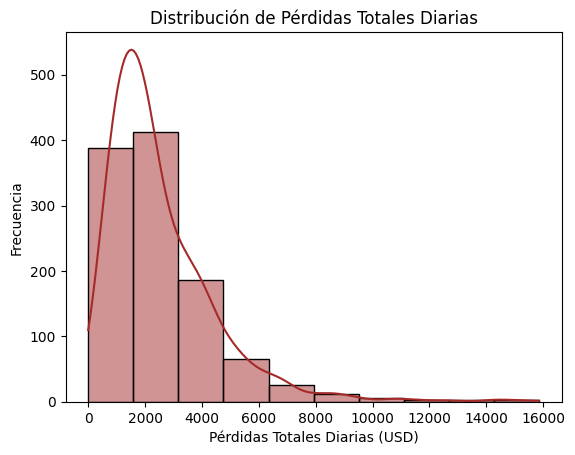

In [ ]:
sns.histplot(df_accidentes['Distribucion_Perdidas_Total_Diaria_USD'], bins=10, kde=True, color='brown')
plt.title('Distribución de Pérdidas Totales Diarias')
plt.xlabel('Pérdidas Totales Diarias (USD)')
plt.ylabel('Frecuencia')
plt.show()

####2. Construccion del histograma de frecuencias

In [ ]:
ni=100 #numero intervalos para agrupar datos
counts, limits=np.histogram(df_accidentes['Distribucion_Perdidas_Total_Diaria_USD'], bins=ni) #agrupar datos en 10 intervalos
LI= limits[:-1] #limites inferiores histograma
LS= limits[1:] #limites superiores histograma
fi=counts/sum(counts) #dividir contador entre la suma de todos los valores. Porcentaje de datos por intervalo
marcaC=(LI+LS)/2 #marca de clase: dato representativo de cada intervalo

df= pd.DataFrame(np.column_stack((LI,LS, counts, fi, marcaC)))
df.columns=['LI','LS','ND', 'fi', 'Marca de clase']
display(df)

,LI,LS,ND,fi,Marca de clase
0,0.000000,158.563174,5.0,0.004541,79.281587
1,158.563174,317.126348,13.0,0.011807,237.844761
2,317.126348,475.689522,28.0,0.025431,396.407935
3,475.689522,634.252697,25.0,0.022707,554.971110
4,634.252697,792.815871,46.0,0.041780,713.534284
...,...,...,...,...,...
95,15063.501545,15222.064720,0.0,0.000000,15142.783132
96,15222.064720,15380.627894,0.0,0.000000,15301.346307
97,15380.627894,15539.191068,0.0,0.000000,15459.909481
98,15539.191068,15697.754242,0.0,0.000000,15618.472655


####3. Medidas de tendencia central

In [ ]:
#media: valor esperado de una perdida
u=np.sum(marcaC*fi) #u= miu
print("la medida de las perdidas es", f"{u:.2f} USD")

#Varianza: dispersion de los datos alrededor de la media
varianzaC=np.sum(((marcaC-u)**2)*fi)
print("la varianza es", f"{varianzaC:.2f} USD\u00b2")

sigma=np.sqrt(varianzaC)
print("la desviacion estandar es", f"{sigma:.2f} USD")

#Intervalo de variacion de las perdidas
#en este intervalo se encuentra el 95% de los datos (2*sigma)
#en este intervalo se encuentra el 68% de los datos (1*sigma)
print("el limite inferior es", f"{u-sigma:.2f} USD")
print("el limite superior es", f"{u+sigma:.2f} USD")

#coeficiente de asimetria
cas=np.sum(((marcaC-u)**3)*fi)/((sigma**3))
print("el coeficiente de asimetria es", f"{cas:.2f}")

la medida de las perdidas es 2538.81 USD
la varianza es 3777852.72 USD²
la desviacion estandar es 1943.67 USD
el limite inferior es 595.14 USD
el limite superior es 4482.48 USD
el coeficiente de asimetria es 2.22


* **Media de pérdidas:** El valor esperado de una pérdida es 2538,81 USD.

* **Varianza:** La dispersión de los datos alrededor de la media es 3777852,72 USD².
* Desviación estándar: La desviación estándar es 1943,67 USD.
* **Intervalo de variación de pérdidas:** el límite inferior es 595,14 USD y el límite superior es 4482,48 USD.
  - *Este intervalo representa el rango en el que se espera que una porción significativa de los datos (por ejemplo, 68% para 1 sigma, 95% para 2 sigma) caiga alrededor de la media.*
* **Coeficiente de asimetría:** El coeficiente de asimetría es 2,22. Un valor positivo indica que la distribución tiene una cola larga hacia la derecha, lo que significa que hay pérdidas extremadamente grandes que pérdidas extremadamente pequeñas.

####4. Calcular curtosis

In [ ]:
import scipy.stats as stats
#Coeficiente de Curtosis
kurt = stats.kurtosis(df_accidentes['Distribucion_Perdidas_Total_Diaria_USD'])
print("El coeficiente de curtosis es", f"{kurt:.2f}")

El coeficiente de curtosis es 8.15


El coeficiente de curtosis de 8,15 indica que la distribución de las pérdidas totales diarias es leptocúrtica. Esto significa que tiene:
* Colas más pesadas: en comparación con una distribución normal (que tiene una curtosis de 3 o un exceso de curtosis de 0), esta distribución tiene más valores atípicos o extremos (pérdidas tanto muy bajas como muy altas).
* Pico más agudo: los datos están más concentrados alrededor de la media, pero esos valores extremos más frecuentes contribuyen a las "colas gruesas".

Una curtosis alta como 8,15 sugiere que AseguraSur SA es más susceptible a pérdidas muy pequeñas o muy grandes de lo que implicaría una distribución normal. Esto es importante para la gestión de riesgos, ya que indica una mayor probabilidad de eventos extremos.

####5. Convertir a excel el dataframe generado por gemini

In [ ]:
df_accidentes.to_excel('df_accidentes.xlsx', index=False)